## Setup Instructions

**Required files** (place all three in the same folder as this notebook):
- buyer.xlsx
- product.xlsx
- sales.xlsx


## Notebook Structure

| Step | Purpose |
|-------|---------|
| Step 1 | Environment setup (library imports, display settings) |
| Step 2 | Data loading and first look |
| Step 3 | Data quality audit |
| Step 4 | Data cleaning and feature engineering |
| Step 5 | Scalable join function |
| Step 6 | Answering the five business questions |

In [1]:
# ============================================================
# Step 1: Environment Setup
# ============================================================

# ── importing libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# ── Display Settings ──
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Plot Style ──
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Environment setup complete. All libraries loaded successfully!")

Environment setup complete. All libraries loaded successfully!


In [2]:
# ============================================================
# Config File paths -
# Data files (buyer.xlsx, product.xlsx, sales.xlsx) should be
# in the same folder as this notebook.
# Charts will be saved to a 'charts' subfolder (auto-created).
# ============================================================

import os
from pathlib import Path

BUYER_PATH   = 'buyer.xlsx'
PRODUCT_PATH = 'product.xlsx'
SALES_PATH   = 'sales.xlsx'

CHART_DIR = 'charts'
Path(CHART_DIR).mkdir(exist_ok=True)

print(f"  Data files expected in current directory")
print(f"  Charts will be saved to: ./{CHART_DIR}/")

  Data files expected in current directory
  Charts will be saved to: ./charts/


In [3]:
# ============================================================
# Step 2: Loading & Inspecting Datasets
# ============================================================

df_buyer   = pd.read_excel(BUYER_PATH)
df_product = pd.read_excel(PRODUCT_PATH)
df_sales   = pd.read_excel(SALES_PATH)

print("DATASET DIMENSIONS:")
print(f"   Buyer   : {df_buyer.shape[0]:,} rows × {df_buyer.shape[1]} columns")
print(f"   Product : {df_product.shape[0]:,} rows × {df_product.shape[1]} columns")
print(f"   Sales   : {df_sales.shape[0]:,} rows × {df_sales.shape[1]} columns")


print("\n" + "="*55)
print("BUYER DATASET — Column Info")
print("="*55)
df_buyer.info()

print("\n" + "="*55)
print("PRODUCT DATASET — Column Info")
print("="*55)
df_product.info()

print("\n" + "="*55)
print("SALES DATASET — Column Info")
print("="*55)
df_sales.info()


print("\n" + "="*55)
print("BUYER — First 5 Rows")
print("="*55)
display(df_buyer.head())

print("\n" + "="*55)
print("PRODUCT — First 5 Rows")
print("="*55)
display(df_product.head())

print("\n" + "="*55)
print("SALES — First 5 Rows")
print("="*55)
display(df_sales.head())

DATASET DIMENSIONS:
   Buyer   : 52,500 rows × 14 columns
   Product : 1,037 rows × 11 columns
   Sales   : 376,004 rows × 6 columns

BUYER DATASET — Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   buyer_id               49866 non-null  object
 1   customer_group         52500 non-null  object
 2   is_active_buyer        52500 non-null  int64 
 3   signup_date            51981 non-null  object
 4   customer_segment       52500 non-null  object
 5   preferred_subcategory  52500 non-null  object
 6   subcategory_pool       52500 non-null  object
 7   preferred_channel      52500 non-null  object
 8   preferred_payment      52500 non-null  object
 9   region                 47261 non-null  object
 10  state                  52500 non-null  object
 11  timezone               49876 non-null  object
 12  is_referre

,buyer_id,customer_group,is_active_buyer,signup_date,customer_segment,preferred_subcategory,subcategory_pool,preferred_channel,preferred_payment,region,state,timezone,is_referred,wishlist_size
0,B12962,Frequent,1,2020-12-10 00:00:00,Bargain Hunter,Socks,"Small Accessories, Phone Cases",Mobile,Other,Central,MN,NaN,0,7
1,B27489,Regular,1,2023-05-17 00:00:00,Beauty Lover,Foundation,"Lipsticks, Skincare",App,Debit Card,East,PA,NaN,0,14
2,B41901,Dormant,0,2023-07-27 00:00:00,Tech Enthusiast,Smart Watches,"Power Banks, Bluetooth Speakers",App,Other,East,GA,America/New_York,1,3
3,B50973,Dormant,0,2018-06-26 00:00:00,Fashion Shopper,Jackets,"Womenâ€™s Tops, Dresses",App,Other,East,NY,America/New_York,1,25
4,B13680,Frequent,1,2021-07-06 00:00:00,Cozy Homemaker,Wall Art,"Scented Candles, Home Fragrance",App,Digital Wallet,West,OR,America/Los_Angeles,0,14



PRODUCT — First 5 Rows


,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock
0,Beauty,PBE,Skincare,PBESK,CPSFP,True,9DC69ECE1503,9.91,0.77,True,90
1,Beauty,PBE,Skincare,PBESK,CPSFP,True,EF523B4FA026,13.42,0.77,True,65
2,Beauty,PBE,Skincare,PBESK,CPSFP,True,C541AC8EF917,60.74,0.77,True,29
3,Beauty,PBE,Skincare,PBESK,CPSFP,True,7CCFBF68193B,55.82,0.77,True,91
4,Beauty,PBE,Skincare,PBESK,CPSFP,True,97FBE210389E,55.17,0.77,True,17



SALES — First 5 Rows


,order_id,buyer_id,sku_id,quantity,order_datetime,order_status
0,O00062060,B10879,PPSTO-PQYYY-E90286460DB4,1.00,2024-07-04 13:14:00,Delivered
1,O00186767,B23775,PCLSO-WQEPS-38FA2B8ECC0C,1.00,2025-07-12 10:24:00,Delivered
2,O00030197,B27328,PSOCY-NKDLI-31BB2CB8CE81,1.00,2024-03-31 10:29:00,Delivered
3,O00110296,B13263,PTGBO-JDTOJ-F5BD3985D601,1.00,2024-11-26 07:41:00,Delivered
4,O00085844,B19369,PBEBA-WQEPS-4381545163AF,1.00,2024-09-14 19:23:00,Delivered


In [4]:
# ============================================================
# Step 3: Data Quality Audit
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# ── HELPER FUNCTION ──────────────────────────────────────────
def run_quality_checks(df_buyer, df_product, df_sales):
    """
    Runs all data quality checks across the three datasets.

    Parameters:
        df_buyer   : buyer DataFrame
        df_product : product DataFrame
        df_sales   : sales DataFrame

    Returns:
        DataFrame with columns:
            - issue_num   : sequential issue number
            - severity    : CRITICAL / SIGNIFICANT / MINOR
            - dataset     : which dataset the issue belongs to
            - issue       : description of the problem found
            - metric      : the specific number/count discovered
            - fix         : planned resolution in Step 4
    """
    issues = []

    def add(severity, dataset, issue, metric, fix):
        issues.append({
            'issue_num' : len(issues) + 1,
            'severity'  : severity,
            'dataset'   : dataset,
            'issue'     : issue,
            'metric'    : metric,
            'fix'       : fix
        })

    # ── Null Checks ─────────────────────────────────────────
    add('CRITICAL', 'Buyer',
        'buyer_id missing (primary join key)',
        f"{df_buyer['buyer_id'].isnull().sum():,} rows ({df_buyer['buyer_id'].isnull().mean()*100:.1f}%)",
        'Drop rows — cannot link to sales without a key')

    add('SIGNIFICANT', 'Buyer',
        'timezone missing',
        f"{df_buyer['timezone'].isnull().sum():,} rows ({df_buyer['timezone'].isnull().mean()*100:.1f}%)",
        'Impute from state — verified 1-to-1 mapping exists')

    add('SIGNIFICANT', 'Buyer',
        'region missing',
        f"{df_buyer['region'].isnull().sum():,} rows ({df_buyer['region'].isnull().mean()*100:.1f}%)",
        'Document gap; use state as geographic fallback')

    add('SIGNIFICANT', 'Sales',
        'order_datetime missing',
        f"{df_sales['order_datetime'].isnull().sum():,} rows",
        'Drop rows — no timestamp means unusable for time analysis')

    add('SIGNIFICANT', 'Sales',
        'order_status missing',
        f"{df_sales['order_status'].isnull().sum():,} rows",
        'Drop rows — cannot confirm if order is valid revenue')

    add('MINOR', 'Sales',
        'buyer_id missing in sales',
        f"{df_sales['buyer_id'].isnull().sum():,} rows",
        'Drop rows — cannot link to buyer profile')

    # ── Data Type Checks ─────────────────────────────────────
    add('SIGNIFICANT', 'Buyer',
        'signup_date stored as text not datetime',
        f"dtype = {df_buyer['signup_date'].dtype}",
        'Convert to datetime using pd.to_datetime()')

    add('SIGNIFICANT', 'Sales',
        'order_datetime stored as text not datetime',
        f"dtype = {df_sales['order_datetime'].dtype}",
        'Convert to datetime using pd.to_datetime()')

    add('MINOR', 'Sales',
        'quantity stored as float64 not integer',
        f"dtype = {df_sales['quantity'].dtype}",
        'Convert to int after handling nulls')

    # ── Duplicate Checks ─────────────────────────────────────
    sales_dupes = df_sales['order_id'].duplicated().sum()
    add('CRITICAL', 'Sales',
        'Duplicate order_ids — identical rows',
        f"{sales_dupes:,} duplicate rows ({sales_dupes/len(df_sales)*100:.1f}% of sales)",
        'Deduplicate on order_id — safe, no information lost')

    # ── Value Distribution Checks ────────────────────────────
    add('MINOR', 'Sales',
        'Typo in order_status: "Deliverred"',
        f"{(df_sales['order_status'] == 'Deliverred').sum():,} rows",
        'Replace "Deliverred" → "Delivered"')

    add('SIGNIFICANT', 'Buyer',
        'is_referred contains invalid value of 2',
        f"{(df_buyer['is_referred'] == 2).sum():,} rows (valid values: 0 or 1 only)",
        'Exclude from referral analysis; treat as unknown')

    neg_margins  = (df_product['profit_margin'] < 0).sum()
    high_margins = (df_product['profit_margin'] > 1).sum()
    add('CRITICAL', 'Product',
        'profit_margin has corrupt values (negative and >1)',
        f"{neg_margins} negative, {high_margins} above 1.0 (e.g. values up to 76.71)",
        'Filter to valid 0–1 decimal range only; flag rest as corrupt')

    extreme_qty = (df_sales['quantity'] > 100).sum()
    add('SIGNIFICANT', 'Sales',
        'Extreme quantity outliers',
        f"{extreme_qty:,} rows with quantity > 100 (max = {df_sales['quantity'].max():,.0f})",
        'Cap at 99th percentile — clearly data entry errors')

    add('MINOR', 'Product',
        'category_id casing inconsistency: "pso" vs "PSO"',
        f"{(df_product['category_id'] == 'pso').sum()} rows with lowercase category_id",
        'Standardize all category_ids to uppercase')

    # ── Date Validity Check ──────────────────────────────────
    temp_dt    = pd.to_datetime(df_sales['order_datetime'], errors='coerce')
    epoch_rows = (temp_dt.dt.year == 1970).sum()
    add('CRITICAL', 'Sales',
        'Corrupt timestamps — year shows as 1970 (Unix epoch zero)',
        f"{epoch_rows:,} rows",
        'Drop rows — 1970-01-01 means timestamp was stored as zero/null')

    # ── Cross-Dataset Join Check ─────────────────────────────
    sales_buyer_ids = set(df_sales['buyer_id'].dropna().unique())
    buyer_table_ids = set(df_buyer['buyer_id'].dropna().unique())
    unmatched       = len(sales_buyer_ids - buyer_table_ids)
    add('CRITICAL', 'Sales + Buyer',
        'Sales buyer_ids with no matching buyer profile',
        f"{unmatched:,} buyer_ids in sales cannot join to buyer table",
        'Use inner join; document exclusion as analytical assumption')

    # ── Encoding Check ───────────────────────────────────────
    for col in ['preferred_subcategory', 'subcategory_pool']:
        bad = df_buyer[col].dropna().str.contains('â€', na=False).sum()
        if bad > 0:
            add('MINOR', 'Buyer',
                f'Encoding corruption in column: {col}',
                f"{bad:,} rows — apostrophe in \"Women\'s\" garbled as â€™",
                'Replace garbled string with correct apostrophe')

    return pd.DataFrame(issues)


# ── RUN ALL CHECKS ───────────────────────────────────────────
dq_report = run_quality_checks(df_buyer, df_product, df_sales)

# ── PRINT CLEAN SUMMARY TABLE ────────────────────────────────
print("=" * 70)
print("   DATA QUALITY AUDIT — ISSUE SUMMARY")
print("=" * 70)

severity_order = {'CRITICAL': 0, 'SIGNIFICANT': 1, 'MINOR': 2}
dq_report_sorted = dq_report.sort_values(
    by='severity',
    key=lambda x: x.map(severity_order)
).reset_index(drop=True)

# ANSI color codes for colored text in Colab output
# \033[ starts the code, 1m = bold, 31m = red, 33m = yellow/orange, 0m = reset
colors = {
    'CRITICAL'    : '\033[1;91m',   # bold red
    'SIGNIFICANT' : '\033[1;38;5;208m',   # bold orange/yellow
    'MINOR'       : '\033[1;93m',   # bold bright yellow
}
RESET = '\033[0m'

for _, row in dq_report_sorted.iterrows():
    color = colors[row['severity']]
    print(f"\n  {color}[{row['severity']}]{RESET} — {row['issue']}")
    print(f"     Dataset : {row['dataset']}")
    print(f"     Found   : {row['metric']}")
    print(f"     Fix     : {row['fix']}")

# ── COUNTS BY SEVERITY ───────────────────────────────────────
print(f"\n{'=' * 70}")
print(f"  Total Issues  : {len(dq_report)}")
for sev in ['CRITICAL', 'SIGNIFICANT', 'MINOR']:
    count = (dq_report['severity'] == sev).sum()
    print(f"  {colors[sev]}{sev:<12}{RESET} : {count}")
print(f"{'=' * 70}")

   DATA QUALITY AUDIT — ISSUE SUMMARY

  [CRITICAL] — buyer_id missing (primary join key)
     Dataset : Buyer
     Found   : 2,634 rows (5.0%)
     Fix     : Drop rows — cannot link to sales without a key

  [CRITICAL] — Corrupt timestamps — year shows as 1970 (Unix epoch zero)
     Dataset : Sales
     Found   : 4,855 rows
     Fix     : Drop rows — 1970-01-01 means timestamp was stored as zero/null

  [CRITICAL] — profit_margin has corrupt values (negative and >1)
     Dataset : Product
     Found   : 111 negative, 170 above 1.0 (e.g. values up to 76.71)
     Fix     : Filter to valid 0–1 decimal range only; flag rest as corrupt

  [CRITICAL] — Duplicate order_ids — identical rows
     Dataset : Sales
     Found   : 131,724 duplicate rows (35.0% of sales)
     Fix     : Deduplicate on order_id — safe, no information lost

  [CRITICAL] — Sales buyer_ids with no matching buyer profile
     Dataset : Sales + Buyer
     Found   : 13,180 buyer_ids in sales cannot join to buyer table
    

In [5]:
# ============================================================
# Step 4: Data Cleaning & Feature Engineering
# ============================================================
# Part A: Fix every issue identified in Step 3
# Part B: Engineer new fields needed for business questions
#───────────────────────────────────────────────────────────────────
# KEY ASSUMPTIONS APPLIED:
# - Company timezone : America/Chicago (Missouri = CST/CDT)
# - Timestamps       : in customer's local timezone per problem statement
# - Referral discount: 10% off first order of referred buyers only
# - Black Friday     : Nov 29 2024, Nov 28 2025 — checked against
#                      customer timezone per problem statement
# - Shipping tiers   : applied to discounted_subtotal (post-discount)
# - Carrier cost     : $4.99 only on delivered orders (not shipped
#                      if cancelled)
# - Cancelled orders : discounted_subtotal preserved as refund amount
#                      gross_revenue and net_profit = $0
# - Dual vendor issue: same product sourced from 2 vendors at different
#                      prices — resolved by preferring active vendor,
#                      then lower price if tie
# - Taxes            : ignored — pre-calculated per problem statement
# ============================================================

# ── Work on copies so Step 2 originals stay untouched ───────
buyer   = df_buyer.copy()
product = df_product.copy()
sales   = df_sales.copy()

print("=" * 55)
print("  Step 4: CLEANING & FEATURE ENGINEERING")
print("=" * 55)
print(f"\n  Starting row counts:")
print(f"  Sales: {len(sales):,} | Buyer: {len(buyer):,} | Product: {len(product):,}")

# ============================================================
# PART A: CLEANING
# ============================================================
print("\n" + "─" * 55)
print("  PART A — CLEANING")
print("─" * 55)

# ── A1: Deduplicate sales FIRST ──────────────────────────────
print("  A1  → Deduplicating sales on order_id...")
sales = sales.drop_duplicates(subset=['order_id'])

# ── A2: Fix order_status typo ────────────────────────────────
print("  A2  → Fixing 'Deliverred' typo in order_status...")
sales['order_status'] = sales['order_status'].replace('Deliverred', 'Delivered')

# ── A3: Drop rows with missing critical sales fields ─────────
print("  A3  → Dropping sales rows with missing critical fields...")
sales = sales.dropna(subset=['order_datetime', 'buyer_id',
                              'order_status', 'quantity'])

# ── A4: Drop buyer rows with missing buyer_id ────────────────
print("  A4  → Dropping buyer rows with missing buyer_id...")
buyer = buyer.dropna(subset=['buyer_id'])

# ── A5: Convert date columns to datetime ─────────────────────
print("  A5  → Converting date columns to datetime...")
sales['order_datetime'] = pd.to_datetime(sales['order_datetime'], errors='coerce')
buyer['signup_date']    = pd.to_datetime(buyer['signup_date'],    errors='coerce')

# ── A6: Drop 1970 corrupt timestamps + any NaT from coerce ───
print("  A6  → Dropping 1970 corrupt timestamps & NaT rows...")
sales = sales[sales['order_datetime'].dt.year != 1970]
sales = sales.dropna(subset=['order_datetime'])

# ── A7: Fix profit_margin corruption ─────────────────────────
print("  A7  → Correcting profit_margin values (divide-by-100 for |x|>1)...")
def clean_profit_margin(margin):
    """
    Corrects corrupted profit_margin values.

    Two groups handled:
        - |margin| > 1       : divide-by-100 correction, preserves sign
        - -1 <= margin <= 1  : valid, kept as-is (incl. genuine negatives)

    Parameters:
        margin : float — raw profit_margin value

    Returns:
        float — corrected margin, sign preserved

    New Field: profit_margin_clean
    """
    if abs(margin) > 1:
        return margin / 100
    else:
        return margin

product['profit_margin_clean'] = product['profit_margin'].apply(clean_profit_margin)

# ── A8: Standardize category_id and subcategory_id casing ────
print("  A8  → Standardizing category_id & subcategory_id to uppercase...")
product['category_id']    = product['category_id'].str.upper()
product['subcategory_id'] = product['subcategory_id'].str.upper()

# ── A9: Resolve duplicate product_num + subcategory_id ───────
print("  A9  → Resolving dual-vendor duplicate products...")
product = (
    product
    .sort_values(
        ['product_num', 'subcategory_id',
         'currently_active_vendor', 'price'],
        ascending=[True, True, False, True]
    )
    .drop_duplicates(subset=['product_num', 'subcategory_id'], keep='first')
    .reset_index(drop=True)
)

# ── A10: Fix encoding corruption in buyer subcategory fields ──
print("  A10 → Fixing UTF-8 encoding corruption in buyer fields...")
buyer['preferred_subcategory'] = buyer['preferred_subcategory'].str.replace('â€™', "'", regex=False)
buyer['subcategory_pool']      = buyer['subcategory_pool'].str.replace('â€™', "'", regex=False)

# ── A11: Impute missing timezones from state ─────────────────
print("  A11 → Imputing missing timezones from state column...")
state_to_tz = (
    buyer[buyer['timezone'].notna()]
    .groupby('state')['timezone']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
buyer['timezone'] = buyer.apply(
    lambda row: state_to_tz.get(row['state'], row['timezone'])
    if pd.isnull(row['timezone']) else row['timezone'],
    axis=1
)

# ── A12: Cap quantity outliers at 99th percentile ────────────
print("  A12 → Capping quantity outliers at 99th percentile...")
q99 = sales['quantity'].quantile(0.99)
sales['quantity'] = sales['quantity'].clip(upper=q99).astype(int)

# ── A13: Set invalid is_referred = 2 to NaN ──────────────────
print("  A13 → Setting invalid is_referred=2 values to NaN...")
buyer['is_referred'] = buyer['is_referred'].replace(2, pd.NA)

print(f"\n  After cleaning:")
print(f"  Sales: {len(sales):,} | Buyer: {len(buyer):,} | Product: {len(product):,}")

# ============================================================
# PART B: FEATURE ENGINEERING
# ============================================================
print("\n" + "─" * 55)
print("  PART B — FEATURE ENGINEERING")
print("─" * 55)

# ── B1: Extract product_num AND subcategory_id from sku_id ───
print("  B1  → Extracting product_num & subcategory_id from sku_id...")
sales['product_num']    = sales['sku_id'].str.split('-').str[-1]
sales['subcategory_id'] = sales['sku_id'].str.split('-').str[0]

# ── B2: Convert order_datetime to CST (company timezone) ─────
print("  B2  → Converting timestamps to CST...")
temp_tz = (
    sales[['order_id', 'buyer_id', 'order_datetime']]
    .merge(buyer[['buyer_id', 'timezone']], on='buyer_id', how='left')
    .drop_duplicates(subset=['order_id'])
)

def convert_to_cst(row):
    """
    Converts datetime to CST using the buyer's local timezone.

    Parameters:
        row : DataFrame row with 'order_datetime' and 'timezone'

    Returns:
        Timezone-aware datetime in America/Chicago (CST/CDT)
        or NaT if timezone or datetime is missing/invalid

    New Field: order_datetime_cst
    """
    try:
        if pd.isnull(row['timezone']) or pd.isnull(row['order_datetime']):
            return pd.NaT
        return (row['order_datetime']
                .tz_localize(row['timezone'])
                .tz_convert('America/Chicago'))
    except Exception:
        return pd.NaT

temp_tz['order_datetime_cst'] = temp_tz.apply(convert_to_cst, axis=1)
cst_map = temp_tz.set_index('order_id')['order_datetime_cst'].to_dict()
sales['order_datetime_cst'] = sales['order_id'].map(cst_map)

# ── B3: Extract time components from CST datetime ────────────
print("  B3  → Extracting hour, date, year, month, quarter from CST...")
sales['order_hour_cst'] = sales['order_datetime_cst'].dt.hour
sales['order_date']     = sales['order_datetime_cst'].dt.date
sales['order_year']     = sales['order_datetime_cst'].dt.year
sales['order_month']    = sales['order_datetime_cst'].dt.month
sales['order_quarter']  = sales['order_datetime_cst'].dt.quarter.map(
    {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
)

# ── B4: Black Friday flag ─────────────────────────────────────
print("  B4  → Creating is_black_friday flag...")
black_friday_dates = {
    2024: pd.Timestamp('2024-11-29').date(),
    2025: pd.Timestamp('2025-11-28').date()
}

sales['is_black_friday'] = sales['order_datetime'].apply(
    lambda dt: 1 if (
        not pd.isnull(dt) and
        dt.date() == black_friday_dates.get(dt.year)
    ) else 0
)

# ── B5: First referred order flag ────────────────────────────
print("  B5  → Creating is_first_referred_order flag...")
referred_buyers = set(buyer[buyer['is_referred'] == 1]['buyer_id'])

first_referred_order_ids = (
    sales[sales['buyer_id'].isin(referred_buyers)]
    .sort_values('order_datetime')
    .groupby('buyer_id')['order_id']
    .first()
    .values
)

sales['is_first_referred_order'] = (
    sales['order_id'].isin(first_referred_order_ids).astype(int)
)

# ── B6: Revenue order flag ────────────────────────────────────
print("  B6  → Creating is_revenue_order flag...")
sales['is_revenue_order'] = (sales['order_status'] == 'Delivered').astype(int)

# ── B7: Merge product info into sales ────────────────────────
print("  B7  → Merging product info into sales...")
sales = sales.merge(
    product[['product_num', 'subcategory_id', 'price',
             'profit_margin_clean', 'category_name', 'subcategory_name']],
    on=['product_num', 'subcategory_id'],
    how='left'
)

# ── B8: Order subtotal (before discounts) ────────────────────
print("  B8  → Calculating order_subtotal (price × quantity)...")
sales['order_subtotal'] = sales['price'] * sales['quantity']

# ── B9: Apply discounts ───────────────────────────────────────
print("  B9  → Applying referral (10%) and Black Friday (20%) discounts...")
sales['referral_discount'] = (
    sales['order_subtotal'] * 0.10 * sales['is_first_referred_order']
)

sales['bf_discount'] = (
    sales['order_subtotal'] * 0.20 * sales['is_black_friday']
)

sales['discounted_subtotal'] = (
    sales['order_subtotal'] - sales['referral_discount'] - sales['bf_discount']
)

# ── B10: Shipping fees ────────────────────────────────────────
print("  B10 → Calculating shipping_fee_charged & carrier_cost...")
def calculate_shipping(order_total):
    """
    Calculates shipping fee charged to customer based on order total.

    Parameters:
        order_total : float — discounted order subtotal

    Returns:
        float — shipping fee ($7.99, $4.99, or $0.00)

    Tiers:
        < $50       → $7.99
        $50–$99.99  → $4.99
        >= $100     → $0.00 (free shipping)
    """
    if order_total < 50:
        return 7.99
    elif order_total < 100:
        return 4.99
    else:
        return 0.00

sales['shipping_fee_charged'] = sales['discounted_subtotal'].apply(calculate_shipping)
sales['carrier_cost'] = 4.99 * sales['is_revenue_order']

# ── B11: Gross revenue and net profit ────────────────────────
print("  B11 → Calculating gross_revenue & net_profit...")
sales['gross_revenue'] = (
    (sales['discounted_subtotal'] + sales['shipping_fee_charged'])
    * sales['is_revenue_order']
)

sales['net_profit'] = (
    (
        (sales['price'] * sales['profit_margin_clean'] * sales['quantity'])
        - sales['referral_discount']
        - sales['bf_discount']
        - sales['carrier_cost']
    )
    * sales['is_revenue_order']
)

# ── Final summary ─────────────────────────────────────────────
print(f"\n  Cleaned & enriched dataset sizes:")
print(f"  Sales   : {len(sales):,} rows × {sales.shape[1]} columns")
print(f"  Buyer   : {len(buyer):,} rows × {buyer.shape[1]} columns")
print(f"  Product : {len(product):,} rows × {product.shape[1]} columns")

  Step 4: CLEANING & FEATURE ENGINEERING

  Starting row counts:
  Sales: 376,004 | Buyer: 52,500 | Product: 1,037

───────────────────────────────────────────────────────
  PART A — CLEANING
───────────────────────────────────────────────────────
  A1  → Deduplicating sales on order_id...
  A2  → Fixing 'Deliverred' typo in order_status...
  A3  → Dropping sales rows with missing critical fields...
  A4  → Dropping buyer rows with missing buyer_id...
  A5  → Converting date columns to datetime...
  A6  → Dropping 1970 corrupt timestamps & NaT rows...
  A7  → Correcting profit_margin values (divide-by-100 for |x|>1)...
  A8  → Standardizing category_id & subcategory_id to uppercase...
  A9  → Resolving dual-vendor duplicate products...
  A10 → Fixing UTF-8 encoding corruption in buyer fields...
  A11 → Imputing missing timezones from state column...
  A12 → Capping quantity outliers at 99th percentile...
  A13 → Setting invalid is_referred=2 values to NaN...

  After cleaning:
  Sales:

In [6]:
# ============================================================
# Step 5: Data Joining Function
# ============================================================
# Provides a reusable function to link the three cleaned
# datasets in a scalable way. Called per question in Step 6
# with only the columns each analysis needs.
#
# JOIN LOGIC:
# Sales → Buyer   : INNER JOIN on buyer_id
#                   Excludes ~22,957 sales rows with no matching
#                   buyer profile — cannot enrich with segment,
#                   region, or referral data without a buyer record
#
# Sales → Product : Already merged in Step 4 (B7)
#                   Product info (price, margin, category) is
#                   already present in the sales DataFrame
#
# ASSUMPTION: Inner join on buyer_id is intentional. Orders
# with no buyer profile are excluded from all segment-level
# analysis. This is documented as an analytical limitation.
# ============================================================

def join_data(sales_df, buyer_df, buyer_cols=None):
    """
    Links sales data with buyer profiles in a scalable way.

    Parameters:
        sales_df   : cleaned sales DataFrame (from Step 4)
        buyer_df   : cleaned buyer DataFrame (from Step 4)
        buyer_cols : list of buyer columns to bring in.
                     If None, brings in all buyer columns.
                     Pass a specific list to keep merges lean.

    Returns:
        DataFrame — sales enriched with requested buyer fields

    Join Type: INNER on buyer_id
        Intentional — excludes orders with no buyer profile
        so segment/region fields are never null post-join.

    Usage Examples:
        # All buyer fields
        df = join_data(sales, buyer)

        # Only what Q1 needs
        df = join_data(sales, buyer, ['buyer_id', 'timezone'])

        # Only what Q2 needs
        df = join_data(sales, buyer,
                       ['buyer_id', 'customer_segment'])
    """
    if buyer_cols is None:
        buyer_cols = buyer_df.columns.tolist()

    # Always ensure buyer_id is included as the join key
    if 'buyer_id' not in buyer_cols:
        buyer_cols = ['buyer_id'] + buyer_cols

    return sales_df.merge(
        buyer_df[buyer_cols],
        on='buyer_id',
        how='inner'
    )


print("=" * 55)
print("  Step 5: JOIN FUNCTION READY")
print("=" * 55)
print("\n  join_data() defined...")
print("  This function joins sales to buyer on buyer_id using an inner join.")
print("  Product info is already in sales from Step 4, so no product merge needed.")


  Step 5: JOIN FUNCTION READY

  join_data() defined...
  This function joins sales to buyer on buyer_id using an inner join.
  Product info is already in sales from Step 4, so no product merge needed.


In [7]:
# ============================================================
# Step 6: Business Question Analysis
# ============================================================

import os
from pathlib import Path

def save_and_show(fig, filename):
    path = os.path.join(CHART_DIR, f"{filename}.png")
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f" \n Saved: {path}")
    plt.show()

Total orders analyzed : 205,008
Peak hour             : 16:00
Lowest hour           : 3:00

Hourly breakdown:
 order_hour_cst  order_count  pct_of_total
           0.00         4660          2.27
           1.00         3157          1.54
           2.00         3976          1.94
           3.00         2229          1.09
           4.00         2900          1.41
           5.00         3926          1.92
           6.00         5608          2.74
           7.00         7304          3.56
           8.00         8700          4.24
           9.00         9563          4.66
          10.00        10138          4.95
          11.00        10714          5.23
          12.00        10748          5.24
          13.00        11394          5.56
          14.00        12065          5.89
          15.00        12618          6.15
          16.00        13284          6.48
          17.00        13050          6.37
          18.00        12935          6.31
          19.00        11870  

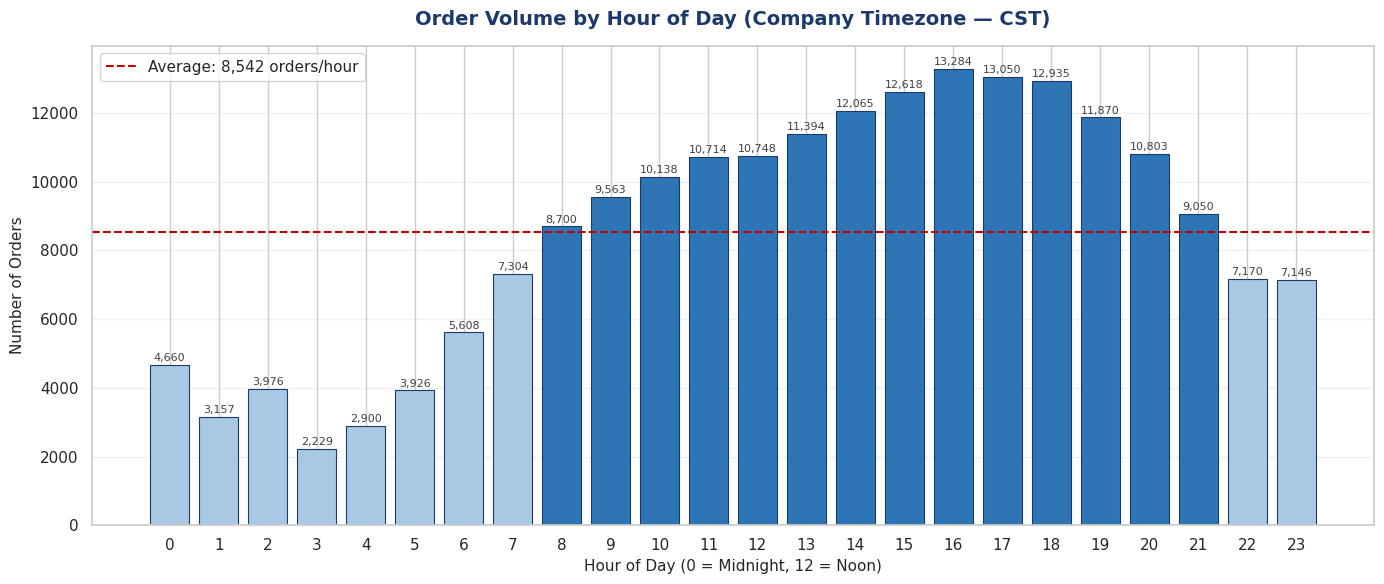

In [8]:
# ═══════════════════════════════════════════════════════════
# Question 1 Analysis
# Order volume by hour (company timezone / CST)
# ═══════════════════════════════════════════════════════════

q1 = sales[sales['order_hour_cst'].notna()].copy()

# Aggregate order count per hour (0-23) across both years
hourly_volume = (
    q1.groupby('order_hour_cst')
      .size()
      .reset_index(name='order_count')
)

# Compute percentage of total
total_orders = hourly_volume['order_count'].sum()
hourly_volume['pct_of_total'] = (hourly_volume['order_count'] / total_orders * 100).round(2)

# Display the table
print(f"Total orders analyzed : {total_orders:,}")
print(f"Peak hour             : {hourly_volume.loc[hourly_volume['order_count'].idxmax(), 'order_hour_cst']:.0f}:00")
print(f"Lowest hour           : {hourly_volume.loc[hourly_volume['order_count'].idxmin(), 'order_hour_cst']:.0f}:00")
print(f"\nHourly breakdown:")
print(hourly_volume.to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Color bars by intensity — darker = more orders
avg = hourly_volume['order_count'].mean()
colors = ['#2E75B6' if v >= avg else '#A8C8E3' for v in hourly_volume['order_count']]

bars = ax.bar(
    hourly_volume['order_hour_cst'],
    hourly_volume['order_count'],
    color=colors,
    edgecolor='#1B3A6B',
    linewidth=0.8
)

# Horizontal line showing average hourly volume
ax.axhline(avg, color='#C00000', linestyle='--', linewidth=1.5,
           label=f'Average: {avg:,.0f} orders/hour')

# Labels on each bar
for bar, count in zip(bars, hourly_volume['order_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=8, color='#404040')

ax.set_title('Order Volume by Hour of Day (Company Timezone — CST)',
             fontsize=14, fontweight='bold', color='#1B3A6B', pad=15)
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left', frameon=True)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
save_and_show(fig, 'q1_hourly_order_volume')

Average Net Profit Per Order ($)
(Delivered orders only)

order_quarter       Q1    Q2    Q3    Q4  Overall
customer_segment                                 
Tech Enthusiast  41.32 40.48 41.02 40.33    40.79
Young Parent     16.08 14.62 16.02 17.74    16.11
Beauty Lover     14.74 13.23 14.55 15.18    14.42
Home Organizer   13.59 15.05 14.26 14.77    14.42
Fitness Buff     13.53 13.31 15.13 14.55    14.13
Cozy Homemaker   13.74 12.66 13.34 15.17    13.73
Bargain Hunter   11.96 11.62 12.18 13.91    12.42
Fashion Shopper   9.86 10.04  9.98 11.19    10.27
 
 Saved: charts/q2_profit_by_segment_quarter.png


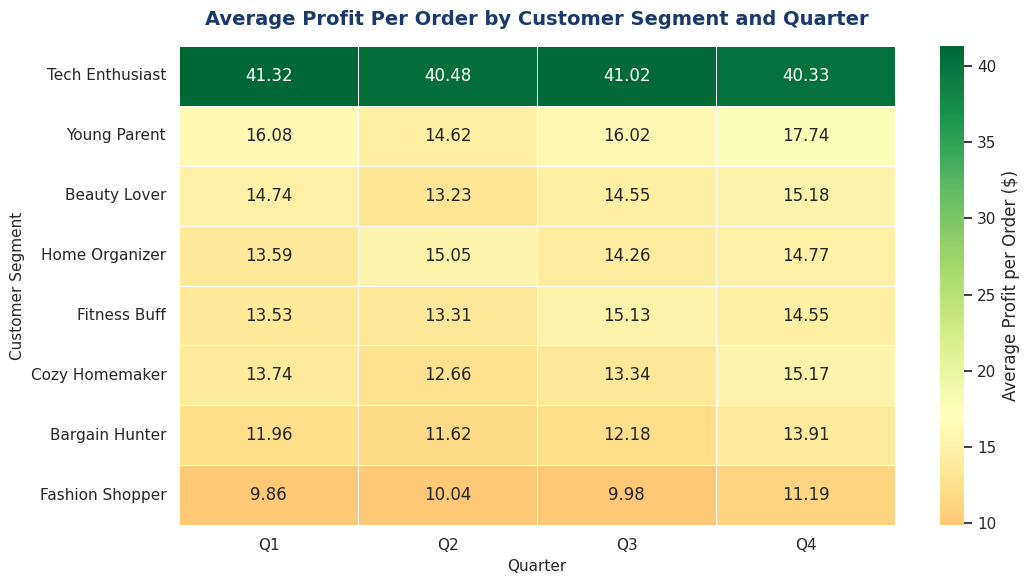

In [9]:
# ═══════════════════════════════════════════════════════════
# Question 2 Analysis
# Average profit per order by quarter and customer segment
# ═══════════════════════════════════════════════════════════

# We need customer_segment from buyer, so use join_data()
q2 = join_data(sales, buyer, ['buyer_id', 'customer_segment'])

# Only delivered orders count toward profit
# (cancelled orders have $0 gross_revenue and $0 net_profit anyway,
#  but filtering explicitly makes the average meaningful)
q2 = q2[q2['is_revenue_order'] == 1]

# Also filter out any rows where order_quarter couldn't be computed
q2 = q2[q2['order_quarter'].notna()]

# Compute average profit per order, grouped by segment and quarter
avg_profit = (
    q2.groupby(['customer_segment', 'order_quarter'])['net_profit']
      .mean()
      .round(2)
      .reset_index()
)

# Pivot into a matrix: segments as rows, quarters as columns
profit_matrix = avg_profit.pivot(
    index='customer_segment',
    columns='order_quarter',
    values='net_profit'
)

# Order quarters properly
profit_matrix = profit_matrix[['Q1', 'Q2', 'Q3', 'Q4']]

# Add a row for "All Quarters" average per segment, and sort segments by it
profit_matrix['Overall'] = profit_matrix.mean(axis=1).round(2)
profit_matrix = profit_matrix.sort_values('Overall', ascending=False)

# Display the table
print("Average Net Profit Per Order ($)")
print("(Delivered orders only)\n")
print(profit_matrix.to_string())

# ── Plot: Heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# Use only Q1-Q4 columns for heatmap (drop the Overall helper column)
heatmap_data = profit_matrix[['Q1', 'Q2', 'Q3', 'Q4']]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',   # red = low profit, green = high profit
    center=heatmap_data.values.mean(),
    cbar_kws={'label': 'Average Profit per Order ($)'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Average Profit Per Order by Customer Segment and Quarter',
             fontsize=14, fontweight='bold', color='#1B3A6B', pad=15)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Customer Segment', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
save_and_show(fig, 'q2_profit_by_segment_quarter')

═══════════════════════════════════════════════════════
  Referral Program — Revenue Lost
═══════════════════════════════════════════════════════
  Total revenue foregone         : $15,624.98
  Number of discounted orders    : 3,595
  Avg discount per referred order: $4.35

═══════════════════════════════════════════════════════
  Referred vs Non-Referred Buyer Comparison
═══════════════════════════════════════════════════════
              num_buyers  avg_orders  avg_revenue  avg_profit  total_revenue  total_profit
Non-Referred       19347        9.35       525.97      155.73  10,175,999.69  3,012,927.83
Referred            3444        9.41       512.13      148.35   1,763,773.97    510,920.23

═══════════════════════════════════════════════════════
  Program Net Impact
═══════════════════════════════════════════════════════
  Total discounts given to referred buyers : $15,624.98
  Total profit generated by referred buyers: $510,920.23
  Net profit after discount cost           : $495

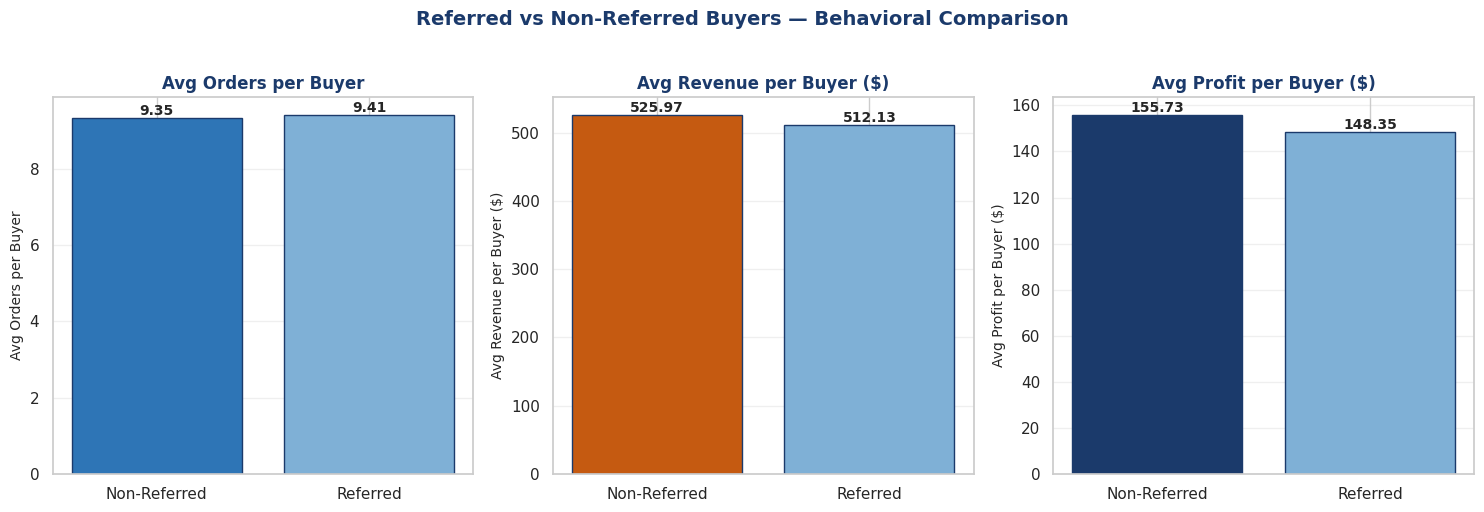

 
 Saved: charts/q3_referral_dollar_impact.png


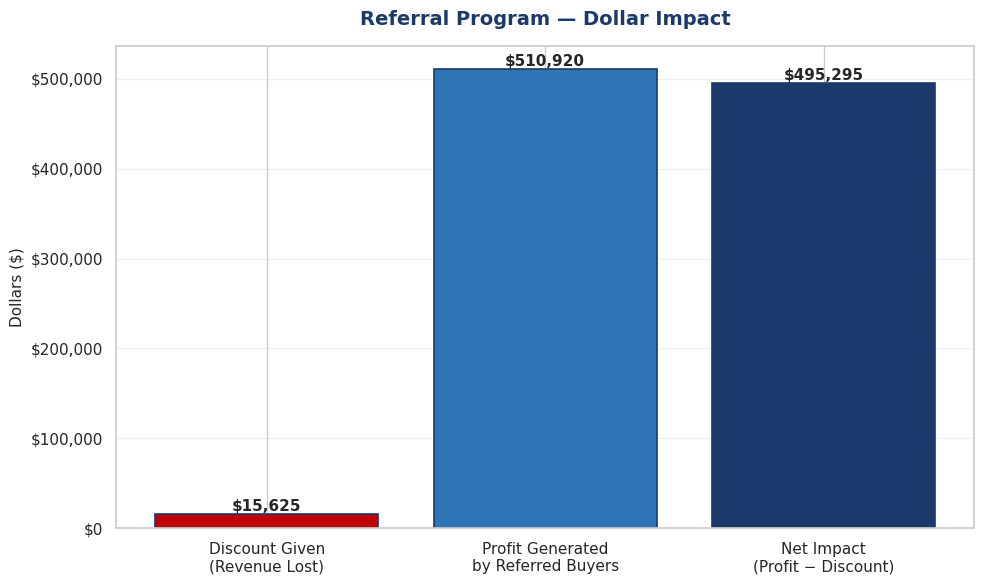

In [10]:
# ═══════════════════════════════════════════════════════════
# Question 3 Analysis
# Revenue lost to referral program + should we continue?
# ═══════════════════════════════════════════════════════════

# We need is_referred from buyer to identify referred buyers
q3 = join_data(sales, buyer, ['buyer_id', 'is_referred', 'customer_segment'])

# ── Part 1: Total revenue lost ──────────────────────────────
# referral_discount captures the exact $ given away per first referred order
# This is "consumed" even if the order gets cancelled (real-world assumption)
total_lost = q3['referral_discount'].sum()
num_discounted_orders = (q3['referral_discount'] > 0).sum()
avg_discount_per_order = q3[q3['referral_discount'] > 0]['referral_discount'].mean()

print("═" * 55)
print("  Referral Program — Revenue Lost")
print("═" * 55)
print(f"  Total revenue foregone         : ${total_lost:,.2f}")
print(f"  Number of discounted orders    : {num_discounted_orders:,}")
print(f"  Avg discount per referred order: ${avg_discount_per_order:,.2f}")

# ── Part 2: Referred vs Non-referred buyer behavior ─────────
# This is the key to answering "should we continue?"
# A referral program is only worth it if referred buyers STAY
# and generate more value than the cost of acquiring them

# Per-buyer summary: how many orders, total revenue, total profit
buyer_behavior = (
    q3[q3['is_referred'].isin([0, 1])]   # exclude the invalid=2 rows
      .groupby(['buyer_id', 'is_referred'])
      .agg(
          orders_placed       = ('order_id', 'count'),
          total_gross_revenue = ('gross_revenue', 'sum'),
          total_net_profit    = ('net_profit', 'sum')
      )
      .reset_index()
)

# Now aggregate across all buyers in each group
comparison = (
    buyer_behavior.groupby('is_referred')
      .agg(
          num_buyers       = ('buyer_id', 'nunique'),
          avg_orders       = ('orders_placed', 'mean'),
          avg_revenue      = ('total_gross_revenue', 'mean'),
          avg_profit       = ('total_net_profit', 'mean'),
          total_revenue    = ('total_gross_revenue', 'sum'),
          total_profit     = ('total_net_profit', 'sum'),
      )
      .round(2)
)
comparison.index = ['Non-Referred', 'Referred']

print("\n" + "═" * 55)
print("  Referred vs Non-Referred Buyer Comparison")
print("═" * 55)
print(comparison.to_string())

# ── Part 3: Net impact of the program ───────────────────────
# Revenue lost = total referral discounts given
# Revenue/profit gained = what referred buyers brought in beyond their first order
# Their first-order profit still happened (just 10% smaller), so we're really
# asking: did we recoup that $15,624 in discounts through repeat purchases?

referred_total_profit = comparison.loc['Referred', 'total_profit']
print("\n" + "═" * 55)
print("  Program Net Impact")
print("═" * 55)
print(f"  Total discounts given to referred buyers : ${total_lost:,.2f}")
print(f"  Total profit generated by referred buyers: ${referred_total_profit:,.2f}")
print(f"  Net profit after discount cost           : ${referred_total_profit - total_lost:,.2f}")
print(f"  Return per $1 of discount                : ${referred_total_profit / total_lost:.2f}")

# ── Chart 1: Referred vs Non-referred averages ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('avg_orders',  'Avg Orders per Buyer',    '#2E75B6'),
    ('avg_revenue', 'Avg Revenue per Buyer ($)', '#C55A11'),
    ('avg_profit',  'Avg Profit per Buyer ($)',  '#1B3A6B'),
]

for ax, (metric, title, color) in zip(axes, metrics):
    values = comparison[metric].values
    bars = ax.bar(comparison.index, values, color=[color, '#7FB0D6'], edgecolor='#1B3A6B')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold', color='#1B3A6B')
    ax.set_ylabel(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle('Referred vs Non-Referred Buyers — Behavioral Comparison',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
plt.tight_layout()
save_and_show(fig, 'q3_referred_vs_nonreferred_comparison')

# ── Chart 2: The dollar story ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Discount Given\n(Revenue Lost)', 'Profit Generated\nby Referred Buyers', 'Net Impact\n(Profit − Discount)']
values = [total_lost, referred_total_profit, referred_total_profit - total_lost]
colors_bars = ['#C00000', '#2E75B6', '#1B3A6B']

bars = ax.bar(categories, values, color=colors_bars, edgecolor='#1B3A6B', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Referral Program — Dollar Impact',
             fontsize=14, fontweight='bold', color='#1B3A6B', pad=15)
ax.set_ylabel('Dollars ($)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
save_and_show(fig, 'q3_referral_dollar_impact')

════════════════════════════════════════════════════════════
  Black Friday vs Regular Day — Overall Impact
════════════════════════════════════════════════════════════
  Total BF orders (2 days)       : 2,331
  Total non-BF orders            : 212,767
  Avg daily volume on BF         : 1,166
  Avg daily volume on other days : 291
  Volume multiplier              : 4.00x

  Total BF revenue               : $107,237.15
  Total non-BF revenue           : $11,930,191.48
  Avg daily revenue on BF        : $53,618.57
  Avg daily revenue on other days: $16,342.73
  Revenue multiplier             : 3.28x

  BF as % of annual order volume : 1.08%
  BF as % of annual revenue      : 0.89%
  Total BF discount given        : $22,925.43

════════════════════════════════════════════════════════════
  Black Friday Lift by Customer Segment
  (daily averages — how many X more activity on BF)
════════════════════════════════════════════════════════════
        segment  bf_daily_volume  normal_daily_volu

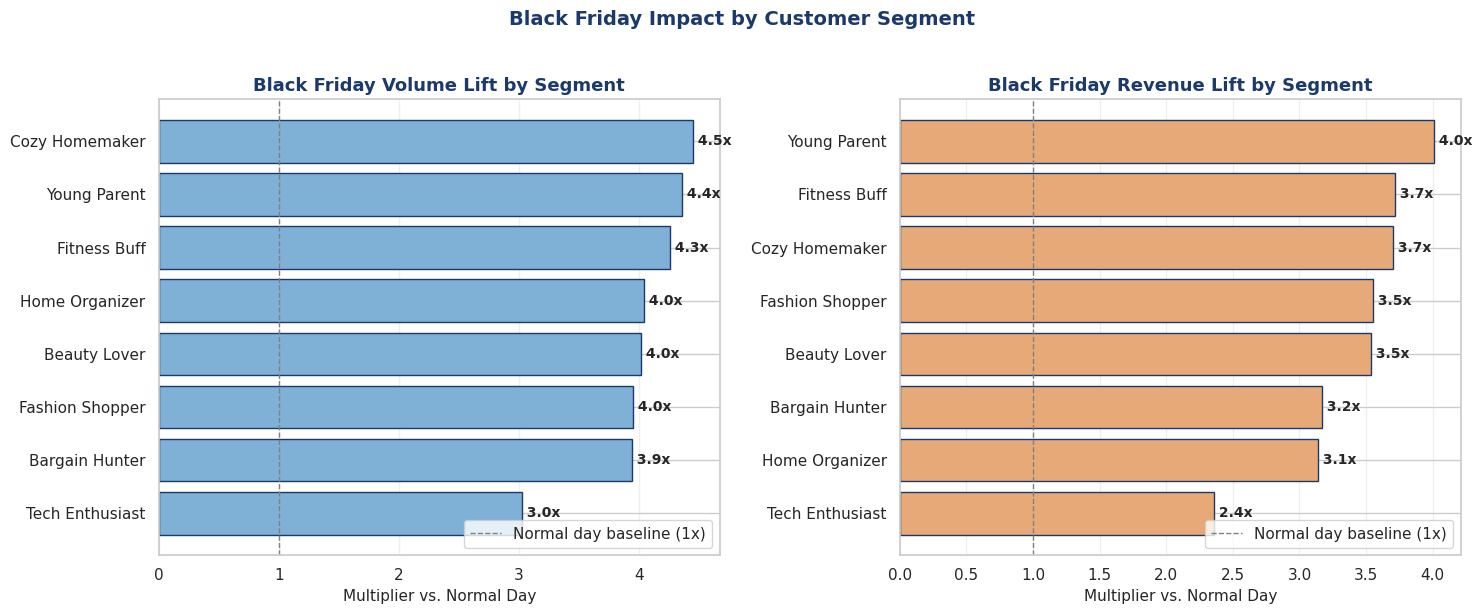

 
 Saved: charts/q4_bf_daily_revenue_comparison.png


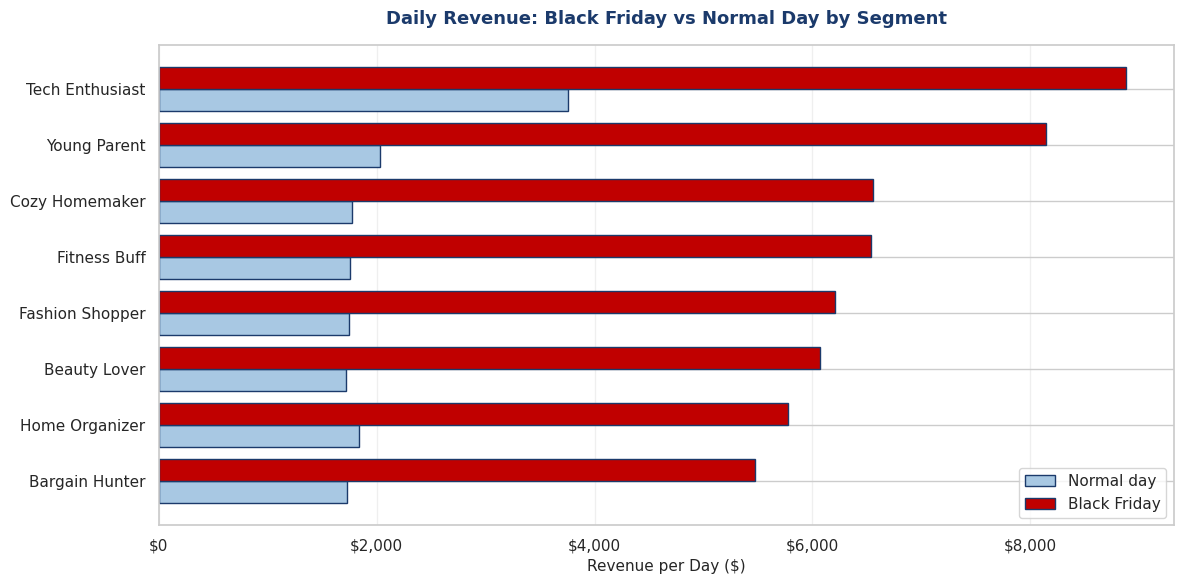

In [11]:
# ═══════════════════════════════════════════════════════════
# Question 4 Analysis
# Black Friday impact on annual sales — volume + revenue
# by customer segment
# ═══════════════════════════════════════════════════════════

# Need customer_segment for segment-level breakdown
q4 = join_data(sales, buyer, ['buyer_id', 'customer_segment'])

# Focus on delivered orders for revenue analysis
# (volume analysis can include cancelled, but revenue must be delivered)
q4_delivered = q4[q4['is_revenue_order'] == 1].copy()

# ── Part 1: Overall Black Friday impact ─────────────────────
# BF spans 2 days total (Nov 29 2024 + Nov 28 2025) out of ~730 days
# So even equal distribution would put BF at 0.27% of the year

bf_orders     = q4[q4['is_black_friday'] == 1]
non_bf_orders = q4[q4['is_black_friday'] == 0]

bf_delivered     = q4_delivered[q4_delivered['is_black_friday'] == 1]
non_bf_delivered = q4_delivered[q4_delivered['is_black_friday'] == 0]

bf_days = 2  # Nov 29 2024 + Nov 28 2025
total_days_in_data = (q4_delivered['order_date'].max() - q4_delivered['order_date'].min()).days + 1
non_bf_days = total_days_in_data - bf_days

avg_daily_volume_bf     = len(bf_orders) / bf_days
avg_daily_volume_non_bf = len(non_bf_orders) / non_bf_days
avg_daily_revenue_bf     = bf_delivered['gross_revenue'].sum() / bf_days
avg_daily_revenue_non_bf = non_bf_delivered['gross_revenue'].sum() / non_bf_days

print("═" * 60)
print("  Black Friday vs Regular Day — Overall Impact")
print("═" * 60)
print(f"  Total BF orders (2 days)       : {len(bf_orders):,}")
print(f"  Total non-BF orders            : {len(non_bf_orders):,}")
print(f"  Avg daily volume on BF         : {avg_daily_volume_bf:,.0f}")
print(f"  Avg daily volume on other days : {avg_daily_volume_non_bf:,.0f}")
print(f"  Volume multiplier              : {avg_daily_volume_bf / avg_daily_volume_non_bf:.2f}x")
print()
print(f"  Total BF revenue               : ${bf_delivered['gross_revenue'].sum():,.2f}")
print(f"  Total non-BF revenue           : ${non_bf_delivered['gross_revenue'].sum():,.2f}")
print(f"  Avg daily revenue on BF        : ${avg_daily_revenue_bf:,.2f}")
print(f"  Avg daily revenue on other days: ${avg_daily_revenue_non_bf:,.2f}")
print(f"  Revenue multiplier             : {avg_daily_revenue_bf / avg_daily_revenue_non_bf:.2f}x")
print()
print(f"  BF as % of annual order volume : {len(bf_orders)/len(q4)*100:.2f}%")
print(f"  BF as % of annual revenue      : {bf_delivered['gross_revenue'].sum()/q4_delivered['gross_revenue'].sum()*100:.2f}%")
print(f"  Total BF discount given        : ${bf_delivered['bf_discount'].sum():,.2f}")

# ── Part 2: By customer segment ─────────────────────────────
# For each segment: BF volume, non-BF volume, BF revenue, non-BF revenue
# and the "lift" (how much BF activity exceeds a normal day)

segment_summary = []
for segment in q4['customer_segment'].unique():
    seg_all = q4[q4['customer_segment'] == segment]
    seg_del = q4_delivered[q4_delivered['customer_segment'] == segment]

    bf_vol  = (seg_all['is_black_friday'] == 1).sum()
    non_bf_vol = (seg_all['is_black_friday'] == 0).sum()
    bf_rev  = seg_del[seg_del['is_black_friday'] == 1]['gross_revenue'].sum()
    non_bf_rev = seg_del[seg_del['is_black_friday'] == 0]['gross_revenue'].sum()

    # Normalize to daily averages to compare fairly
    bf_daily_vol  = bf_vol / bf_days
    non_bf_daily_vol = non_bf_vol / non_bf_days
    bf_daily_rev  = bf_rev / bf_days
    non_bf_daily_rev = non_bf_rev / non_bf_days

    segment_summary.append({
        'segment': segment,
        'bf_daily_volume':   round(bf_daily_vol, 0),
        'normal_daily_volume': round(non_bf_daily_vol, 0),
        'volume_lift':       round(bf_daily_vol / non_bf_daily_vol, 2),
        'bf_daily_revenue':  round(bf_daily_rev, 0),
        'normal_daily_revenue': round(non_bf_daily_rev, 0),
        'revenue_lift':      round(bf_daily_rev / non_bf_daily_rev, 2),
    })

seg_df = pd.DataFrame(segment_summary).sort_values('volume_lift', ascending=False).reset_index(drop=True)

print("\n" + "═" * 60)
print("  Black Friday Lift by Customer Segment")
print("  (daily averages — how many X more activity on BF)")
print("═" * 60)
print(seg_df.to_string(index=False))

# ── Chart 1: Volume and Revenue lift by segment ─────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Volume lift
seg_sorted_vol = seg_df.sort_values('volume_lift', ascending=True)
colors_vol = ['#2E75B6' if v >= 5 else '#7FB0D6' for v in seg_sorted_vol['volume_lift']]
axes[0].barh(seg_sorted_vol['segment'], seg_sorted_vol['volume_lift'], color=colors_vol, edgecolor='#1B3A6B')
for i, v in enumerate(seg_sorted_vol['volume_lift']):
    axes[0].text(v, i, f' {v:.1f}x', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(1, color='gray', linestyle='--', linewidth=1, label='Normal day baseline (1x)')
axes[0].set_title('Black Friday Volume Lift by Segment', fontsize=13, fontweight='bold', color='#1B3A6B')
axes[0].set_xlabel('Multiplier vs. Normal Day', fontsize=11)
axes[0].legend(loc='lower right')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_axisbelow(True)

# Revenue lift
seg_sorted_rev = seg_df.sort_values('revenue_lift', ascending=True)
colors_rev = ['#C55A11' if v >= 5 else '#E8A978' for v in seg_sorted_rev['revenue_lift']]
axes[1].barh(seg_sorted_rev['segment'], seg_sorted_rev['revenue_lift'], color=colors_rev, edgecolor='#1B3A6B')
for i, v in enumerate(seg_sorted_rev['revenue_lift']):
    axes[1].text(v, i, f' {v:.1f}x', va='center', fontsize=10, fontweight='bold')
axes[1].axvline(1, color='gray', linestyle='--', linewidth=1, label='Normal day baseline (1x)')
axes[1].set_title('Black Friday Revenue Lift by Segment', fontsize=13, fontweight='bold', color='#1B3A6B')
axes[1].set_xlabel('Multiplier vs. Normal Day', fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle('Black Friday Impact by Customer Segment',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
plt.tight_layout()
save_and_show(fig, 'q4_bf_lift_by_segment')

# ── Chart 2: Absolute BF contribution ───────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

seg_sorted_abs = seg_df.sort_values('bf_daily_revenue', ascending=True)
x = range(len(seg_sorted_abs))
width = 0.4

ax.barh([i - width/2 for i in x], seg_sorted_abs['normal_daily_revenue'],
        height=width, color='#A8C8E3', edgecolor='#1B3A6B', label='Normal day')
ax.barh([i + width/2 for i in x], seg_sorted_abs['bf_daily_revenue'],
        height=width, color='#C00000', edgecolor='#1B3A6B', label='Black Friday')

ax.set_yticks(list(x))
ax.set_yticklabels(seg_sorted_abs['segment'])
ax.set_xlabel('Revenue per Day ($)', fontsize=11)
ax.set_title('Daily Revenue: Black Friday vs Normal Day by Segment',
             fontsize=13, fontweight='bold', color='#1B3A6B', pad=15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
save_and_show(fig, 'q4_bf_daily_revenue_comparison')

════════════════════════════════════════════════════════════
  Geographic Performance by REGION
════════════════════════════════════════════════════════════
         total_orders  unique_buyers  total_revenue  total_profit  avg_order_value  profit_per_buyer
region                                                                                              
West            71094           8221   4,365,642.86  1,293,071.41            58.99            157.29
East            53823           6237   3,241,959.33    969,724.48            58.05            155.48
Central         35738           4123   2,126,329.84    621,434.03            57.25            150.72
NaN             19889           2287   1,202,366.64    349,686.64            58.27            152.90
Other           18341           2124   1,101,129.96    318,573.57            57.69            149.99

════════════════════════════════════════════════════════════
  Geographic Performance by STATE (Top 10 by Total Profit)
═══════════════

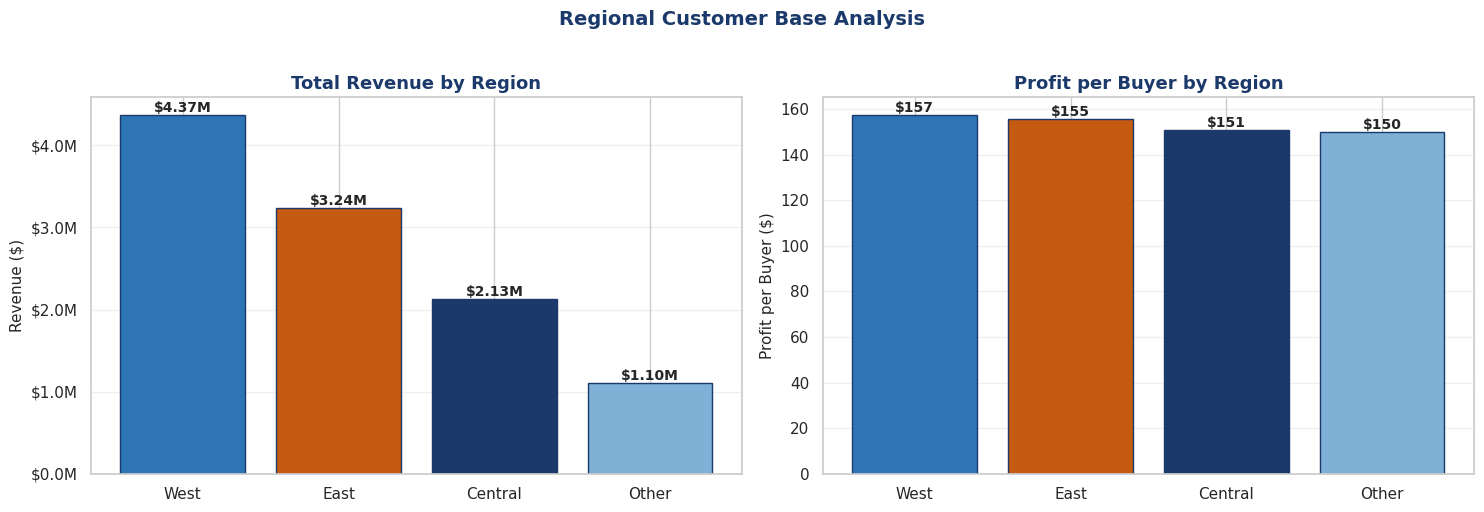

 
 Saved: charts/q5_top10_states_profit.png


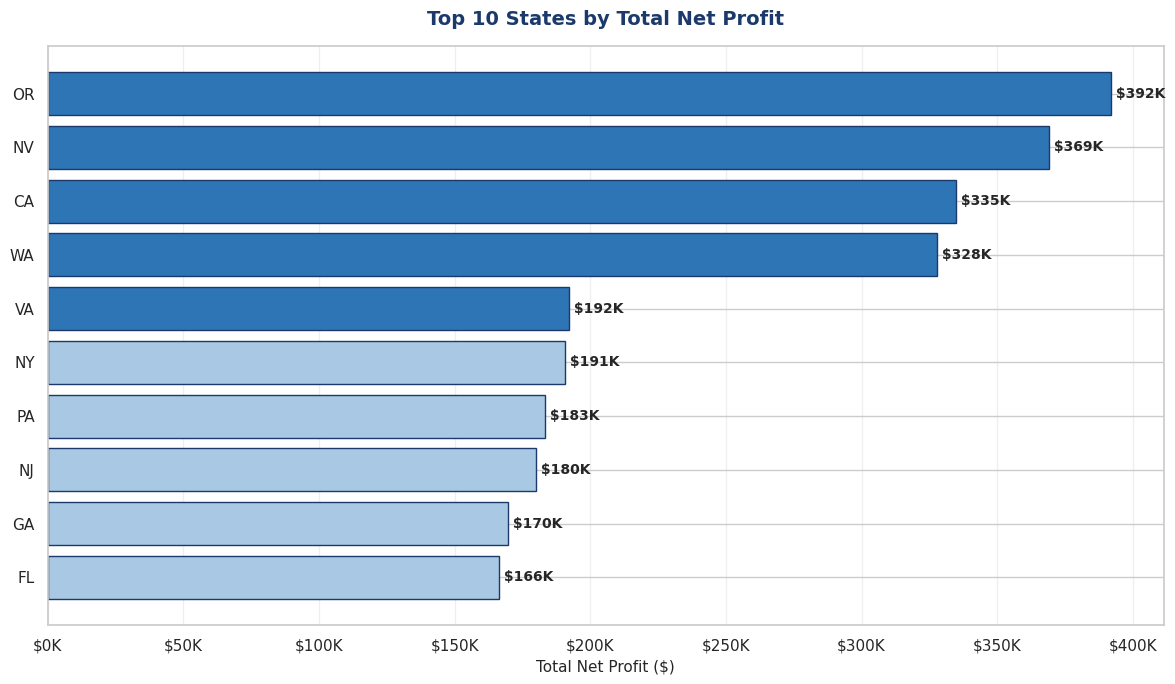

In [12]:
# ═══════════════════════════════════════════════════════════
# Question 5 Analysis
# Best customer base (by region/state) + KPIs to track growth
# ═══════════════════════════════════════════════════════════

# Need region, state, and customer_segment from buyer
q5 = join_data(sales, buyer, ['buyer_id', 'region', 'state', 'customer_segment'])

# For geographic revenue/profit analysis, only delivered orders
q5_delivered = q5[q5['is_revenue_order'] == 1].copy()

# ── Part 1: By Region ───────────────────────────────────────
# "Other" region values exist in the data — we'll keep them but flag
# Nulls in region are expected (~10%) — we'll use state-level fallback

region_summary = (
    q5_delivered.groupby('region', dropna=False)
      .agg(
          total_orders       = ('order_id', 'nunique'),
          unique_buyers      = ('buyer_id', 'nunique'),
          total_revenue      = ('gross_revenue', 'sum'),
          total_profit       = ('net_profit', 'sum'),
          avg_order_value    = ('gross_revenue', 'mean'),
      )
      .round(2)
      .sort_values('total_profit', ascending=False)
)

# Add profit per buyer (a more fair comparison metric since regions have
# very different buyer counts)
region_summary['profit_per_buyer'] = (
    region_summary['total_profit'] / region_summary['unique_buyers']
).round(2)

print("═" * 60)
print("  Geographic Performance by REGION")
print("═" * 60)
print(region_summary.to_string())

# ── Part 2: By State ────────────────────────────────────────
# State has zero nulls — cleaner geographic breakdown

state_summary = (
    q5_delivered.groupby('state')
      .agg(
          total_orders       = ('order_id', 'nunique'),
          unique_buyers      = ('buyer_id', 'nunique'),
          total_revenue      = ('gross_revenue', 'sum'),
          total_profit       = ('net_profit', 'sum'),
          avg_order_value    = ('gross_revenue', 'mean'),
      )
      .round(2)
)
state_summary['profit_per_buyer'] = (
    state_summary['total_profit'] / state_summary['unique_buyers']
).round(2)
state_summary = state_summary.sort_values('total_profit', ascending=False)

print("\n" + "═" * 60)
print("  Geographic Performance by STATE (Top 10 by Total Profit)")
print("═" * 60)
print(state_summary.head(10).to_string())

# ── Part 3: Top segment per region ──────────────────────────
# What kind of customer dominates each region?
seg_by_region = (
    q5_delivered.groupby(['region', 'customer_segment'])['net_profit']
      .sum()
      .reset_index()
)

top_seg_per_region = (
    seg_by_region.sort_values('net_profit', ascending=False)
      .groupby('region')
      .head(3)
      .sort_values(['region', 'net_profit'], ascending=[True, False])
)

print("\n" + "═" * 60)
print("  Top 3 Customer Segments by Profit per Region")
print("═" * 60)
print(top_seg_per_region.to_string(index=False))

# ── Chart 1: Revenue & Profit by Region ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Filter out NaN region for visualization
plot_regions = region_summary[region_summary.index.notna()].copy()

colors_region = ['#2E75B6', '#C55A11', '#1B3A6B', '#7FB0D6']

# Revenue
axes[0].bar(plot_regions.index, plot_regions['total_revenue'],
            color=colors_region[:len(plot_regions)], edgecolor='#1B3A6B')
for i, v in enumerate(plot_regions['total_revenue']):
    axes[0].text(i, v, f'${v/1e6:.2f}M', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].set_title('Total Revenue by Region', fontsize=13, fontweight='bold', color='#1B3A6B')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

# Profit per buyer (fair comparison)
axes[1].bar(plot_regions.index, plot_regions['profit_per_buyer'],
            color=colors_region[:len(plot_regions)], edgecolor='#1B3A6B')
for i, v in enumerate(plot_regions['profit_per_buyer']):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Profit per Buyer by Region', fontsize=13, fontweight='bold', color='#1B3A6B')
axes[1].set_ylabel('Profit per Buyer ($)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle('Regional Customer Base Analysis',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
plt.tight_layout()
save_and_show(fig, 'q5_region_performance')

# ── Chart 2: Top 10 States by Profit ────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

top10 = state_summary.head(10).sort_values('total_profit', ascending=True)
colors_bars = ['#2E75B6' if v >= top10['total_profit'].median() else '#A8C8E3'
               for v in top10['total_profit']]

bars = ax.barh(top10.index, top10['total_profit'], color=colors_bars, edgecolor='#1B3A6B')
for bar, val in zip(bars, top10['total_profit']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f' ${val/1000:,.0f}K', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 States by Total Net Profit',
             fontsize=14, fontweight='bold', color='#1B3A6B', pad=15)
ax.set_xlabel('Total Net Profit ($)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
save_and_show(fig, 'q5_top10_states_profit')